--- Testing with Random Vectors ---
Random Data Fit -> Slope: -0.1444, Intercept: 5.9969

--- Testing with Custom Linear Function ---
Original Equation: y = 5.0000x + 3.0000
Custom LS Result : y = 5.1976x + 2.8752
Numpy LS Result  : y = 5.1976x + 2.8752
-> Comparison: Custom LS perfectly matches Numpy's lstsq!

--- Residual Analysis ---
Largest Residual Error:  1.0261 (at X=0.04, Actual Y=4.1092)
Smallest Residual Error: 0.0028 (at X=0.67, Actual Y=6.3549)


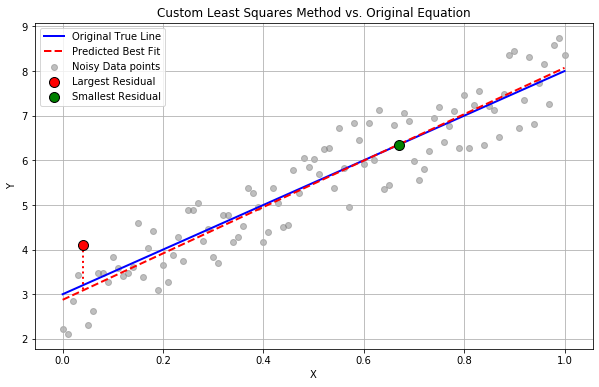

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def custom_least_squares(x, y):
    """
    Custom Least Squares implementation using the Normal Equations.
    Returns the slope (m) and intercept (b).
    """
    # Stack the x vector with a column of ones to form the design matrix A
    A = np.vstack([x, np.ones(len(x))]).T
    
    # Calculate (A^T * A)^-1 * A^T * y
    A_T = A.T
    A_T_A_inv = np.linalg.inv(A_T.dot(A))
    beta = A_T_A_inv.dot(A_T).dot(y)
    
    return beta[0], beta[1]

# ==========================================
# 1. Test with Random Vectors (Sorted X)
# ==========================================
print("--- Testing with Random Vectors ---")
# Generate 15 random points, ensuring X is sorted
X_rand = np.sort(np.random.rand(15) * 10)
Y_rand = np.random.rand(15) * 10

m_rand, b_rand = custom_least_squares(X_rand, Y_rand)
print(f"Random Data Fit -> Slope: {m_rand:.4f}, Intercept: {b_rand:.4f}\n")

# ==========================================
# 2. Custom Linear Function & Data Generation
# ==========================================
print("--- Testing with Custom Linear Function ---")
# True equation: y = 5x + 3
true_m = 5.0
true_b = 3.0

# X from 0 to 1, steps of .01
X_cust = np.arange(0, 1.01, 0.01)

# Calculate Y with a +/- random error between 0 and 1
# We use uniform(-1, 1) to represent adding OR subtracting a random number up to 1
error = np.random.uniform(-1, 1, len(X_cust))
Y_cust = (true_m * X_cust) + true_b + error

# ==========================================
# 3. Compare Custom LS against Numpy LS
# ==========================================
# Run custom method
m_cust, b_cust = custom_least_squares(X_cust, Y_cust)

# Run Numpy method for comparison
A_np = np.vstack([X_cust, np.ones(len(X_cust))]).T
m_np, b_np = np.linalg.lstsq(A_np, Y_cust, rcond=None)[0]

print(f"Original Equation: y = {true_m:.4f}x + {true_b:.4f}")
print(f"Custom LS Result : y = {m_cust:.4f}x + {b_cust:.4f}")
print(f"Numpy LS Result  : y = {m_np:.4f}x + {b_np:.4f}")

# Verify they match perfectly
if np.allclose([m_cust, b_cust], [m_np, b_np]):
    print("-> Comparison: Custom LS perfectly matches Numpy's lstsq!\n")
else:
    print("-> Comparison: Mismatch found.\n")

# ==========================================
# 4. Residual Analysis
# ==========================================
print("--- Residual Analysis ---")
# Calculate the predicted Y values based on our custom fit
Y_pred = m_cust * X_cust + b_cust

# Calculate absolute residuals (difference between actual Y and predicted Y)
residuals = np.abs(Y_cust - Y_pred)

# Find the indices of the largest and smallest residuals
max_res_idx = np.argmax(residuals)
min_res_idx = np.argmin(residuals)

print(f"Largest Residual Error:  {residuals[max_res_idx]:.4f} (at X={X_cust[max_res_idx]:.2f}, Actual Y={Y_cust[max_res_idx]:.4f})")
print(f"Smallest Residual Error: {residuals[min_res_idx]:.4f} (at X={X_cust[min_res_idx]:.2f}, Actual Y={Y_cust[min_res_idx]:.4f})")

# ==========================================
# 5. Plotting
# ==========================================
plt.figure(figsize=(10, 6))

# Plot the noisy data points
plt.scatter(X_cust, Y_cust, color='gray', alpha=0.5, label='Noisy Data points')

# Plot the True Line and Predicted Line
plt.plot(X_cust, true_m * X_cust + true_b, color='blue', linewidth=2, label='Original True Line')
plt.plot(X_cust, Y_pred, color='red', linestyle='--', linewidth=2, label='Predicted Best Fit')

# Highlight the points with the largest and smallest residuals
plt.scatter(X_cust[max_res_idx], Y_cust[max_res_idx], color='red', s=100, edgecolor='black', zorder=5, label='Largest Residual')
plt.scatter(X_cust[min_res_idx], Y_cust[min_res_idx], color='green', s=100, edgecolor='black', zorder=5, label='Smallest Residual')

# Connect the max residual to the fit line to visually show the error
plt.plot([X_cust[max_res_idx], X_cust[max_res_idx]], 
         [Y_cust[max_res_idx], Y_pred[max_res_idx]], 
         color='red', linestyle=':', linewidth=2)

plt.title("Custom Least Squares Method vs. Original Equation")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)
plt.show()